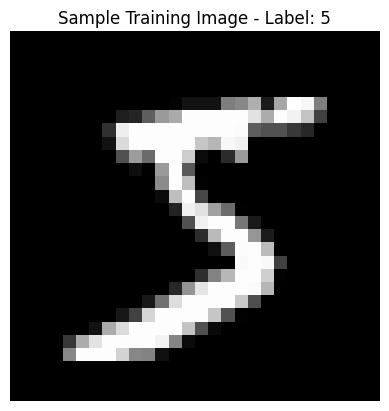

Training set shape: (60000, 28, 28, 1)
Testing set shape: (10000, 28, 28, 1)
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 42s 87ms/step - accuracy: 0.9391 - loss: 0.2057 - val_accuracy: 0.9801 - val_loss: 0.0612
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 84ms/step - accuracy: 0.9827 - loss: 0.0575 - val_accuracy: 0.9874 - val_loss: 0.0400
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 39s 84ms/step - accuracy: 0.9875 - loss: 0.0417 - val_accuracy: 0.9872 - val_loss: 0.0450
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 39s 84ms/step - accuracy: 0.9903 - loss: 0.0318 - val_accuracy: 0.9884 - val_loss: 0.0339
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 39s 84ms/step - accuracy: 0.9927 - loss: 0.0241 - val_accuracy: 0.9895 - val_loss: 0.0312
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9895 - loss: 0.0312
Test accuracy: 0.9895
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Predicted classes: [7 2 1 0 4]
True labels: [7 2 1 0 4]


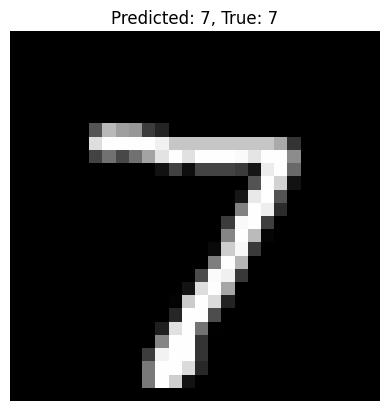

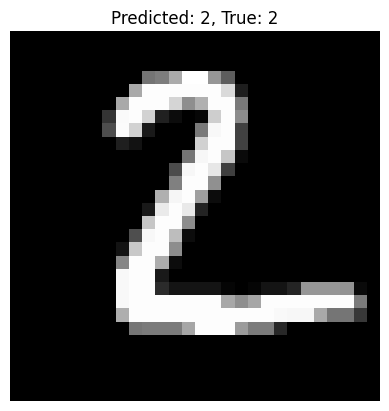

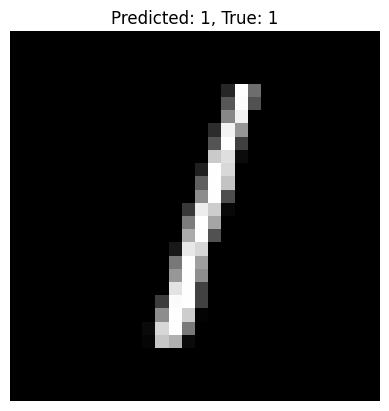

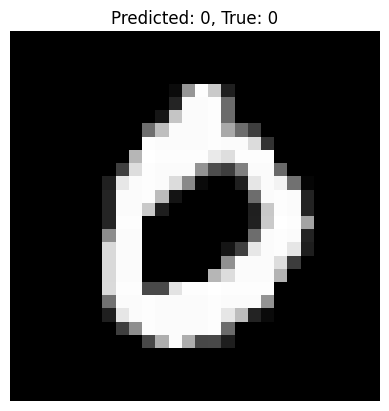

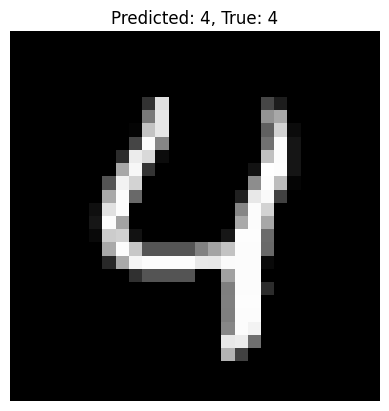

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# 1. Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Show a sample image BEFORE training
plt.imshow(x_train[0], cmap="gray")
plt.title(f"Sample Training Image - Label: {y_train[0]}")
plt.axis("off")
plt.show()

# 2. Preprocess data
# Reshaping the images so that they can work with Keras API
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1).astype("float32") / 255.0
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1).astype("float32") / 255.0
print("Training set shape:", x_train.shape)  # (60000, 28, 28, 1)
print("Testing set shape:", x_test.shape)    # (10000, 28, 28, 1)

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 3. Build CNN model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

# 4. Compile model
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# 5. Train model
history=model.fit(x_train, y_train, epochs=5, batch_size=128,
          validation_data=(x_test, y_test))

# 6. Evaluate model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

# 7. Predict on first 5 test images
predictions = model.predict(x_test[:5])
predicted_classes = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test[:5], axis=1)

print("Predicted classes:", predicted_classes)
print("True labels:", true_labels)

# Show sample images AFTER testing with predictions
for i in range(5):
    plt.imshow(x_test[i].reshape(28,28), cmap="gray")
    plt.title(f"Predicted: {predicted_classes[i]}, True: {true_labels[i]}")
    plt.axis("off")
    plt.show()


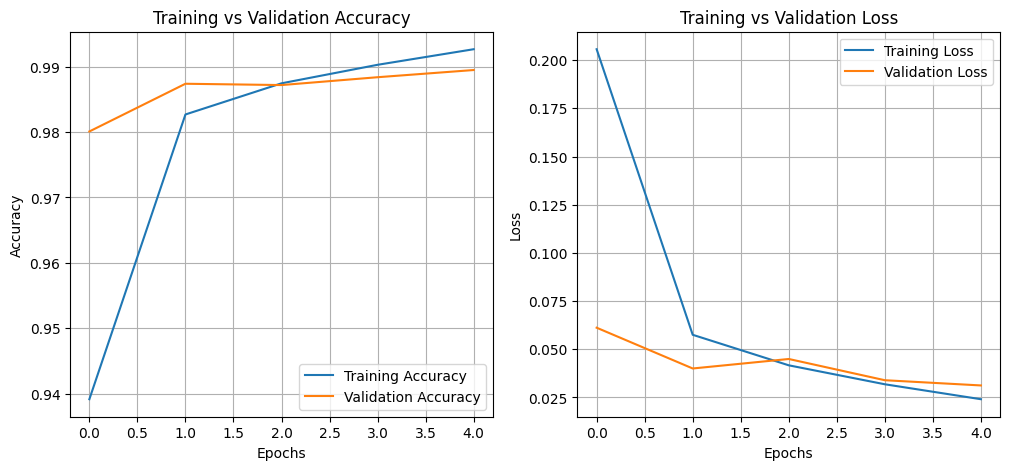

In [5]:
# Plot Training & Validation Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Training & Validation Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()